In [1]:
import rasterio
from tqdm import tqdm
import pandas as pd
import os


import cv2, gc
import numpy as np
import cupy as cp

import matplotlib.pyplot as plt

In [2]:
def get_patch_area_condition(rgb_patch, red_band_patch, green_band_patch, blue_band_patch, red_edge_band_patch, nir_band_patch, 
                             patch_thresh_area):
    cond_area = None
    if rgb_patch is not None:
        rgb_patch_gray = cv2.cvtColor(rgb_patch.get(), cv2.COLOR_RGB2GRAY)
        rgb_patch_total_area = np.where(rgb_patch_gray != 0, 1, 0).sum()
        cond_area = rgb_patch_total_area

        cond = rgb_patch_total_area <= patch_thresh_area

        del rgb_patch_gray
    else:
        red_band_patch_normalzied = cv2.normalize(red_band_patch.get(), None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)
        green_band_patch_normalzied = cv2.normalize(green_band_patch.get(), None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)
        blue_band_patch_normalzied = cv2.normalize(blue_band_patch.get(), None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)
        red_edge_band_patch_normalzied = cv2.normalize(red_edge_band_patch.get(), None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)
        nir_band_patch_normalzied = cv2.normalize(nir_band_patch.get(), None, 255, 0, cv2.NORM_MINMAX, cv2.CV_8U)

        red_total_area = np.where(red_band_patch_normalzied != 0, 1, 0).sum()
        green_total_area = np.where(green_band_patch_normalzied != 0, 1, 0).sum()
        blue_total_area = np.where(blue_band_patch_normalzied != 0, 1, 0).sum()
        red_edge_total_area = np.where(red_edge_band_patch_normalzied != 0, 1, 0).sum()
        nir_total_area = np.where(nir_band_patch_normalzied != 0, 1, 0).sum()

        cond_area = np.max([red_total_area, green_total_area, blue_total_area, red_edge_total_area, nir_total_area])

        cond = (red_total_area <= patch_thresh_area) or (green_total_area <= patch_thresh_area) or \
                (blue_total_area <= patch_thresh_area) or (red_edge_total_area <= patch_thresh_area) or (nir_total_area <= patch_thresh_area)
        
        
        del red_band_patch_normalzied, green_band_patch_normalzied, blue_band_patch_normalzied, red_edge_band_patch_normalzied, nir_band_patch_normalzied
    
    gc.collect()

    return cond, cond_area

In [3]:
def get_ms_bands(orthomosaic_dir, prefix=""):       # This function is added by Mendee
        # Determine where the file is with its path.
        #orthopath = f"{orthomosaic_dir}/{prefix}_2024.tif"
        orthopath = orthomosaic_dir
        if not os.path.exists(orthopath):
            print("Path doesn't exist!!!")
            # print(NameError(orthopath))
            raise FileNotFoundError(f"The file {orthopath} does not exist.")
            
            
        with rasterio.open(orthopath) as src:
            red_band = cp.array(src.read(3))
            blue_band = cp.array(src.read(1))   # I hope my notes are correct about these band numbering.
            green_band = cp.array(src.read(2))
            red_edge_band = cp.array(src.read(4))
            nir_band = cp.array(src.read(5))
        
        # stack = cp.stack((red_band, green_band, blue_band, red_edge_band, nir_band), axis=2)
        dictio = {
            'red': red_band,
            'blue': blue_band,
            'green': green_band,
            'red edge': red_edge_band,
            'nir': nir_band
        }
        return src, dictio

In [4]:
file_path = "/media/razydave/01DA189A333B10701/MendeFolder/08_BelceeriinDoroitol/Drone_Orthomosaics/Orthos2024_09/Altum/Worst_09/worst_september_altum_ortho.tif"
#src_worst = rasterio.open(file_path)
src_worst, worst_altum_september_ortho_dict = get_ms_bands(file_path)

Path doesn't exist!!!


FileNotFoundError: The file /media/razydave/01DA189A333B10701/MendeFolder/08_BelceeriinDoroitol/Drone_Orthomosaics/Orthos2024_09/Altum/Worst_09/worst_september_altum_ortho.tif does not exist.

In [5]:
print(src_worst)


NameError: name 'src_worst' is not defined

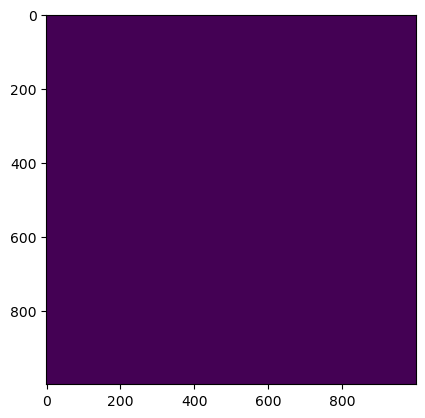

In [6]:
red_band = worst_altum_september_ortho_dict['red']
blue_band = worst_altum_september_ortho_dict['blue']
green_band = worst_altum_september_ortho_dict['green']
red_edge_band = worst_altum_september_ortho_dict['red edge']
nir_band = worst_altum_september_ortho_dict['nir']

# One patch
start_vertical = 4000
end_vertical = 5000
start_horizontal = 6000
end_horizontal = 7000

cond = None
rgb_patch = None

red_band_patch = red_band[start_vertical:end_vertical, start_horizontal:end_horizontal]
green_band_patch = green_band[start_vertical:end_vertical, start_horizontal:end_horizontal]
blue_band_patch = blue_band[start_vertical:end_vertical, start_horizontal:end_horizontal]
red_edge_band_patch = red_edge_band[start_vertical:end_vertical, start_horizontal:end_horizontal]
nir_band_patch = nir_band[start_vertical:end_vertical, start_horizontal:end_horizontal]

plt.imshow(red_band_patch.get())

In [7]:
import rasterio.plot
rasterio.plot.show(src_worst)

RasterioIOError: Dataset is closed: /media/razydave/01DA189A333B10701/MendeFolder/08_BelceeriinDoroitol/Drone_Orthomosaics/Orthos2024_09/Altum/Worst_09/worst_september_altum_ortho.tif

In [8]:
src_worst.close()

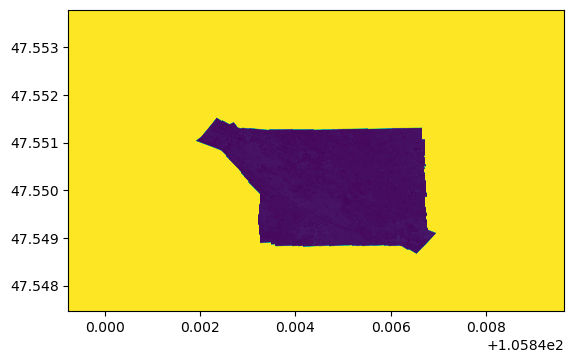

<Axes: >

In [9]:
src_new_worst = rasterio.open(file_path)
rasterio.plot.show(src_new_worst)

Conclusion: It was because of Bad ortho stitching in Agisoft Metashape. Don't know why the plot shown above has so many unused space.